### Required Try-It Activity 14.1: Grid Searching Decision Trees 

This try-it focuses on performing a grid search with a `DecisionTreeClassifier`.  As mentioned in the lectures, the grid search for a tree model can get large very easily. In addition to using `GridSearchCV`, scikitlearn implements additional tools that can save energy and offer alternatives to the brute force exhaustive search.  Below, you will compare the performance of some of these alternatives and discuss the time these searches take.  Note that this will be in large part determined by your personal computing power however the relative speed of the searches should be consistent.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_halving_search_cv
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV, HalvingRandomSearchCV

In [13]:
# Define a comprehensive parameter grid for the DecisionTreeClassifier
params = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None],
    'min_samples_split': [2, 3, 5, 7, 10, 15, 20, 30],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_leaf': [1, 2, 3, 5, 7, 10, 15, 20]
}

# Calculate total number of parameter combinations
total_combinations = 1
for key, values in params.items():
    total_combinations *= len(values)
print(f"Total parameter combinations: {total_combinations}")

Total parameter combinations: 2112


In [14]:
dtree = DecisionTreeClassifier()

### Comparing Grid Searches

Below, explore the four grid search options using the same parameter selections for the `DecisionTreeClassifier`. All of the grid searching tools have a `.cv_results_` attribute after fitting that contains information after fitting including time.  Use this to compare the time of each search and discuss what you believe the "best" approach to identifying the hyperparameters of the model are between:

- `GridSearchCV`
- `RandomizedSearchCV`
- `HalvingGridSearchCV`
- `HalvingRandomSearchCV`

Share your results in a plot comparing the different times for searching across the different parameters as well as the score of the different estimators that resulted from the grid search.  

In [15]:
# Load and preprocess the Whickham dataset
df = pd.read_csv('data/Whickham.txt')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

print("\nDataset info:")
print(df.info())
print("\nTarget distribution:")
print(df['outcome'].value_counts())


Dataset shape: (1314, 3)

First few rows:


,outcome,smoker,age
0,Alive,Yes,23
1,Alive,Yes,18
2,Dead,Yes,71
3,Alive,No,67
4,Alive,No,64



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   outcome  1314 non-null   object
 1   smoker   1314 non-null   object
 2   age      1314 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 30.9+ KB
None

Target distribution:
outcome
Alive    945
Dead     369
Name: count, dtype: int64


In [16]:
# Preprocess the data
# Convert categorical variables to numeric
df_processed = df.copy()

# Encode 'outcome': Dead = 1, Alive = 0 (we're predicting death)
df_processed['outcome'] = (df_processed['outcome'] == 'Dead').astype(int)

# Encode 'smoker': Yes = 1, No = 0
df_processed['smoker'] = (df_processed['smoker'] == 'Yes').astype(int)

print("Processed dataset:")
display(df_processed.head())

# Define features (X) and target (y)
X = df_processed[['smoker', 'age']]
y = df_processed['outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))


Processed dataset:


,outcome,smoker,age
0,0,1,23
1,0,1,18
2,1,1,71
3,0,0,67
4,0,0,64



Training set size: 1051
Test set size: 263

Target distribution in training set:
outcome
0    0.719315
1    0.280685
Name: proportion, dtype: float64


In [17]:
import time
import warnings
warnings.filterwarnings('ignore')

# Dictionary to store results from all grid searches
results = {}

# Common settings
cv_folds = 5
random_state = 42
scoring = 'accuracy'


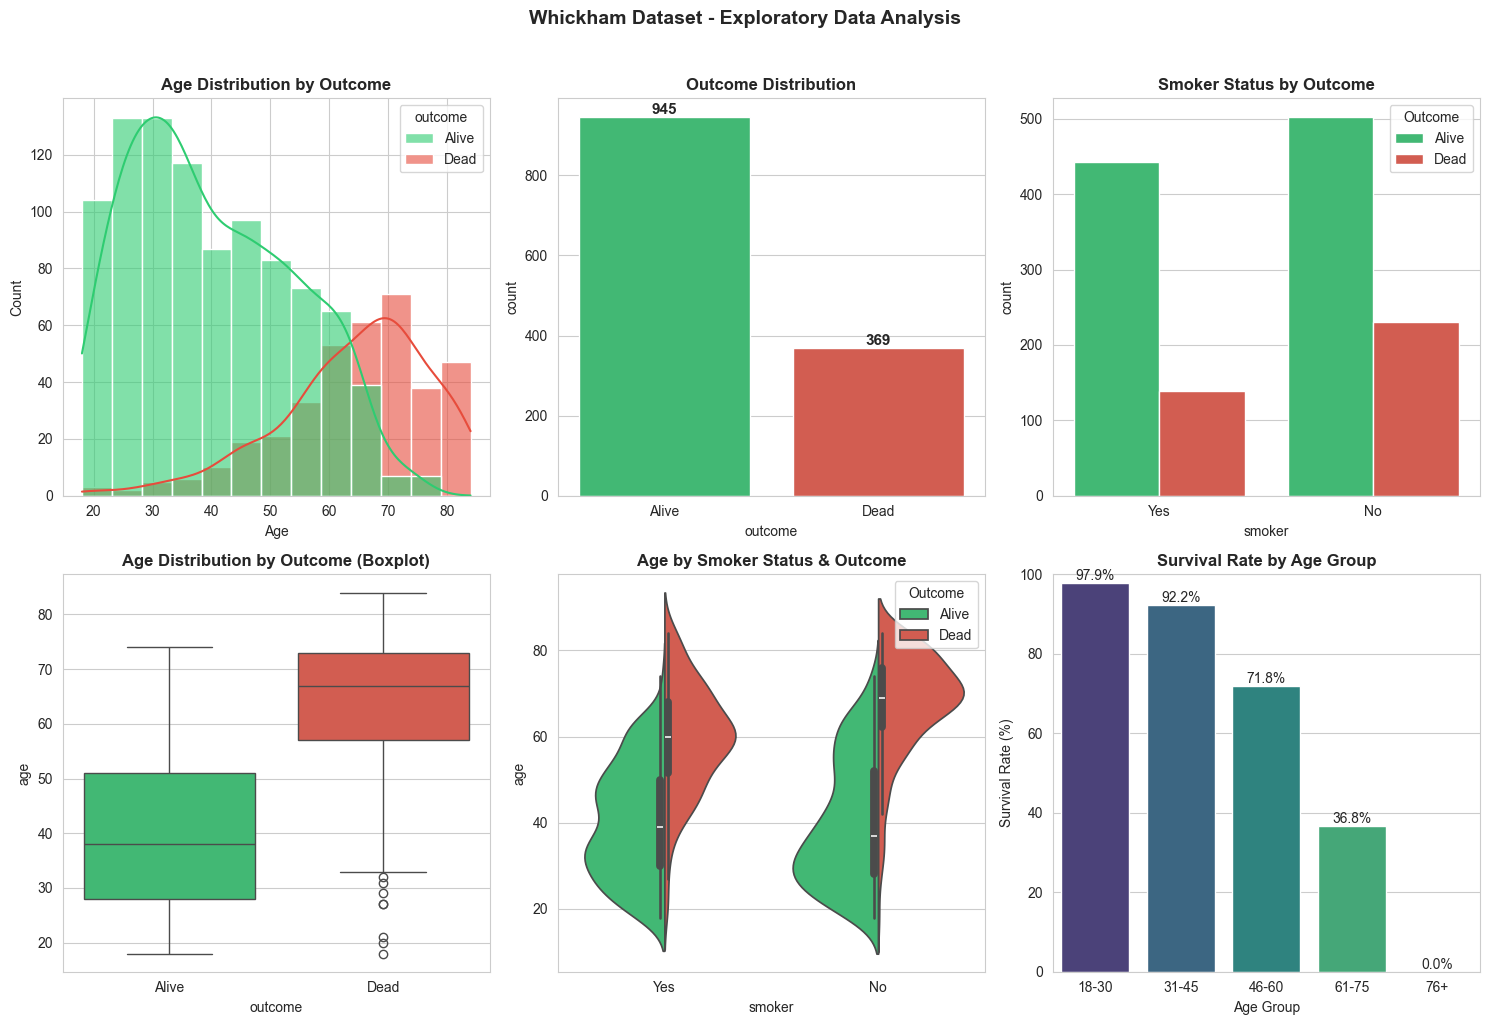


SUMMARY STATISTICS BY OUTCOME
         count       mean        std   min   25%   50%   75%   max
outcome                                                           
Alive    945.0  40.084656  13.849342  18.0  28.0  38.0  51.0  74.0
Dead     369.0  64.425474  12.842715  18.0  57.0  67.0  73.0  84.0


In [18]:
# Exploratory Data Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Set style
sns.set_style("whitegrid")
palette = {'Alive': '#2ecc71', 'Dead': '#e74c3c'}

# Plot 1: Age Distribution by Outcome
ax1 = axes[0, 0]
sns.histplot(data=df, x='age', hue='outcome', kde=True, ax=ax1, palette=palette, alpha=0.6)
ax1.set_title('Age Distribution by Outcome', fontsize=12, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Count')

# Plot 2: Outcome Distribution (Count)
ax2 = axes[0, 1]
sns.countplot(data=df, x='outcome', hue='outcome', palette=palette, ax=ax2, legend=False)
ax2.set_title('Outcome Distribution', fontsize=12, fontweight='bold')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 3: Smoker Distribution by Outcome
ax3 = axes[0, 2]
sns.countplot(data=df, x='smoker', hue='outcome', palette=palette, ax=ax3)
ax3.set_title('Smoker Status by Outcome', fontsize=12, fontweight='bold')
ax3.legend(title='Outcome')

# Plot 4: Age Boxplot by Outcome
ax4 = axes[1, 0]
sns.boxplot(data=df, x='outcome', y='age', hue='outcome', palette=palette, ax=ax4, legend=False)
ax4.set_title('Age Distribution by Outcome (Boxplot)', fontsize=12, fontweight='bold')

# Plot 5: Age Violin Plot by Outcome and Smoker Status
ax5 = axes[1, 1]
sns.violinplot(data=df, x='smoker', y='age', hue='outcome', split=True, palette=palette, ax=ax5)
ax5.set_title('Age by Smoker Status & Outcome', fontsize=12, fontweight='bold')
ax5.legend(title='Outcome', loc='upper right')

# Plot 6: Survival Rate by Age Group
ax6 = axes[1, 2]
df_temp = df.copy()
df_temp['age_group'] = pd.cut(df_temp['age'], bins=[0, 30, 45, 60, 75, 100], 
                               labels=['18-30', '31-45', '46-60', '61-75', '76+'])
survival_rate = df_temp.groupby('age_group', observed=True)['outcome'].apply(
    lambda x: (x == 'Alive').sum() / len(x) * 100
).reset_index(name='survival_rate')
bars = sns.barplot(data=survival_rate, x='age_group', y='survival_rate', ax=ax6, 
                   hue='age_group', palette='viridis', legend=False)
ax6.set_title('Survival Rate by Age Group', fontsize=12, fontweight='bold')
ax6.set_xlabel('Age Group')
ax6.set_ylabel('Survival Rate (%)')
ax6.set_ylim(0, 100)
for p in ax6.patches:
    ax6.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Whickham Dataset - Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS BY OUTCOME")
print("=" * 60)
print(df.groupby('outcome')['age'].describe())


In [19]:
# 1. GridSearchCV - Exhaustive search over all parameter combinations
print("=" * 60)
print("1. GRIDSEARCHCV - Exhaustive Search")
print("=" * 60)

start_time = time.time()

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_grid=params,
    cv=cv_folds,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

grid_time = time.time() - start_time

print(f"\nTime elapsed: {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
print(f"Test set score: {grid_search.score(X_test, y_test):.4f}")
print(f"Total fits: {len(grid_search.cv_results_['mean_test_score'])}")

# Store results
results['GridSearchCV'] = {
    'time': grid_time,
    'best_score': grid_search.best_score_,
    'test_score': grid_search.score(X_test, y_test),
    'best_params': grid_search.best_params_,
    'total_fits': len(grid_search.cv_results_['mean_test_score']),
    'cv_results': grid_search.cv_results_
}


1. GRIDSEARCHCV - Exhaustive Search
Fitting 5 folds for each of 2112 candidates, totalling 10560 fits

Time elapsed: 4.91 seconds
Best parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best CV score: 0.8526
Test set score: 0.8479
Total fits: 2112


In [20]:
# 2. RandomizedSearchCV - Random sampling of parameter combinations
print("=" * 60)
print("2. RANDOMIZEDSEARCHCV - Random Sampling")
print("=" * 60)

# Use n_iter to control number of parameter combinations to try
# Setting to ~10% of total combinations for a fair comparison
n_iter = max(50, total_combinations // 10)
print(f"Number of iterations: {n_iter}")

start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_distributions=params,
    n_iter=n_iter,
    cv=cv_folds,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=random_state,
    return_train_score=True
)

random_search.fit(X_train, y_train)

random_time = time.time() - start_time

print(f"\nTime elapsed: {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV score: {random_search.best_score_:.4f}")
print(f"Test set score: {random_search.score(X_test, y_test):.4f}")
print(f"Total fits: {len(random_search.cv_results_['mean_test_score'])}")

# Store results
results['RandomizedSearchCV'] = {
    'time': random_time,
    'best_score': random_search.best_score_,
    'test_score': random_search.score(X_test, y_test),
    'best_params': random_search.best_params_,
    'total_fits': len(random_search.cv_results_['mean_test_score']),
    'cv_results': random_search.cv_results_
}


2. RANDOMIZEDSEARCHCV - Random Sampling
Number of iterations: 211
Fitting 5 folds for each of 211 candidates, totalling 1055 fits

Time elapsed: 0.58 seconds
Best parameters: {'min_samples_split': 20, 'min_samples_leaf': 15, 'max_depth': 5, 'criterion': 'log_loss'}
Best CV score: 0.8526
Test set score: 0.8479
Total fits: 211


In [21]:
# 3. HalvingGridSearchCV - Successive halving with exhaustive grid
print("=" * 60)
print("3. HALVINGGRIDSEARCHCV - Successive Halving with Full Grid")
print("=" * 60)

start_time = time.time()

halving_grid_search = HalvingGridSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_grid=params,
    cv=cv_folds,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=random_state,
    factor=3,  # Each iteration discards 2/3 of candidates
    min_resources='exhaust'  # Use as much data as possible
)

halving_grid_search.fit(X_train, y_train)

halving_grid_time = time.time() - start_time

print(f"\nTime elapsed: {halving_grid_time:.2f} seconds")
print(f"Best parameters: {halving_grid_search.best_params_}")
print(f"Best CV score: {halving_grid_search.best_score_:.4f}")
print(f"Test set score: {halving_grid_search.score(X_test, y_test):.4f}")
print(f"Number of iterations: {halving_grid_search.n_iterations_}")
print(f"Total candidates: {halving_grid_search.n_candidates_}")

# Store results
results['HalvingGridSearchCV'] = {
    'time': halving_grid_time,
    'best_score': halving_grid_search.best_score_,
    'test_score': halving_grid_search.score(X_test, y_test),
    'best_params': halving_grid_search.best_params_,
    'total_fits': len(halving_grid_search.cv_results_['mean_test_score']),
    'cv_results': halving_grid_search.cv_results_,
    'n_iterations': halving_grid_search.n_iterations_
}


3. HALVINGGRIDSEARCHCV - Successive Halving with Full Grid
n_iterations: 4
n_required_iterations: 7
n_possible_iterations: 4
min_resources_: 20
max_resources_: 1051
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 2112
n_resources: 20
Fitting 5 folds for each of 2112 candidates, totalling 10560 fits
----------
iter: 1
n_candidates: 704
n_resources: 60
Fitting 5 folds for each of 704 candidates, totalling 3520 fits
----------
iter: 2
n_candidates: 235
n_resources: 180
Fitting 5 folds for each of 235 candidates, totalling 1175 fits
----------
iter: 3
n_candidates: 79
n_resources: 540
Fitting 5 folds for each of 79 candidates, totalling 395 fits

Time elapsed: 6.52 seconds
Best parameters: {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 15}
Best CV score: 0.8601
Test set score: 0.8479
Number of iterations: 4
Total candidates: [2112, 704, 235, 79]


In [24]:
# 4. HalvingRandomSearchCV - Successive halving with random sampling
print("=" * 60)
print("4. HALVINGRANDOMSEARCHCV - Successive Halving with Random Sampling")
print("=" * 60)

start_time = time.time()

halving_random_search = HalvingRandomSearchCV(
    estimator=DecisionTreeClassifier(random_state=random_state),
    param_distributions=params,
    cv=cv_folds,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=random_state,
    factor=3,
    min_resources='smallest',
    n_candidates='exhaust'  # Sample as many candidates as possible
)

halving_random_search.fit(X_train, y_train)

halving_random_time = time.time() - start_time

print(f"\nTime elapsed: {halving_random_time:.2f} seconds")
print(f"Best parameters: {halving_random_search.best_params_}")
print(f"Best CV score: {halving_random_search.best_score_:.4f}")
print(f"Test set score: {halving_random_search.score(X_test, y_test):.4f}")
print(f"Number of iterations: {halving_random_search.n_iterations_}")
print(f"Total candidates: {halving_random_search.n_candidates_}")

# Store results
results['HalvingRandomSearchCV'] = {
    'time': halving_random_time,
    'best_score': halving_random_search.best_score_,
    'test_score': halving_random_search.score(X_test, y_test),
    'best_params': halving_random_search.best_params_,
    'total_fits': len(halving_random_search.cv_results_['mean_test_score']),
    'cv_results': halving_random_search.cv_results_,
    'n_iterations': halving_random_search.n_iterations_
}

4. HALVINGRANDOMSEARCHCV - Successive Halving with Random Sampling
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 20
max_resources_: 1051
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 52
n_resources: 20
Fitting 5 folds for each of 52 candidates, totalling 260 fits
----------
iter: 1
n_candidates: 18
n_resources: 60
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 2
n_candidates: 6
n_resources: 180
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 2
n_resources: 540
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Time elapsed: 0.48 seconds
Best parameters: {'min_samples_split': 15, 'min_samples_leaf': 1, 'max_depth': 2, 'criterion': 'log_loss'}
Best CV score: 0.8601
Test set score: 0.8479
Number of iterations: 4
Total candidates: [52, 18, 6, 2]


## Comparative Analysis of Grid Search Methods

Now let's create a comprehensive comparison of all four grid search methods, analyzing:
1. **Execution Time** - How long each method takes
2. **Best CV Score** - The best cross-validation score achieved
3. **Test Set Score** - Performance on unseen data
4. **Total Fits** - Number of model fits performed
5. **Efficiency** - Score achieved per unit of time


In [25]:
# Create a summary comparison DataFrame
summary_data = []

for method, data in results.items():
    summary_data.append({
        'Method': method,
        'Time (seconds)': round(data['time'], 3),
        'Best CV Score': round(data['best_score'], 4),
        'Test Score': round(data['test_score'], 4),
        'Total Fits': data['total_fits'],
        'Efficiency (Score/Time)': round(data['best_score'] / data['time'], 4) if data['time'] > 0 else np.inf
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Method')

print("=" * 80)
print("SUMMARY COMPARISON OF GRID SEARCH METHODS")
print("=" * 80)
display(summary_df)

# Highlight best values
print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("=" * 80)
print(f"🏆 Fastest method: {summary_df['Time (seconds)'].idxmin()} ({summary_df['Time (seconds)'].min():.3f}s)")
print(f"🎯 Best CV Score: {summary_df['Best CV Score'].idxmax()} ({summary_df['Best CV Score'].max():.4f})")
print(f"✅ Best Test Score: {summary_df['Test Score'].idxmax()} ({summary_df['Test Score'].max():.4f})")
print(f"⚡ Most Efficient: {summary_df['Efficiency (Score/Time)'].idxmax()}")


SUMMARY COMPARISON OF GRID SEARCH METHODS


,Time (seconds),Best CV Score,Test Score,Total Fits,Efficiency (Score/Time)
Method,,,,,
GridSearchCV,4.911,0.8526,0.8479,2112,0.1736
RandomizedSearchCV,0.578,0.8526,0.8479,211,1.4738
HalvingGridSearchCV,6.523,0.8601,0.8479,3130,0.1319
HalvingRandomSearchCV,0.476,0.8601,0.8479,78,1.8060



KEY FINDINGS:
🏆 Fastest method: HalvingRandomSearchCV (0.476s)
🎯 Best CV Score: HalvingGridSearchCV (0.8601)
✅ Best Test Score: GridSearchCV (0.8479)
⚡ Most Efficient: HalvingRandomSearchCV


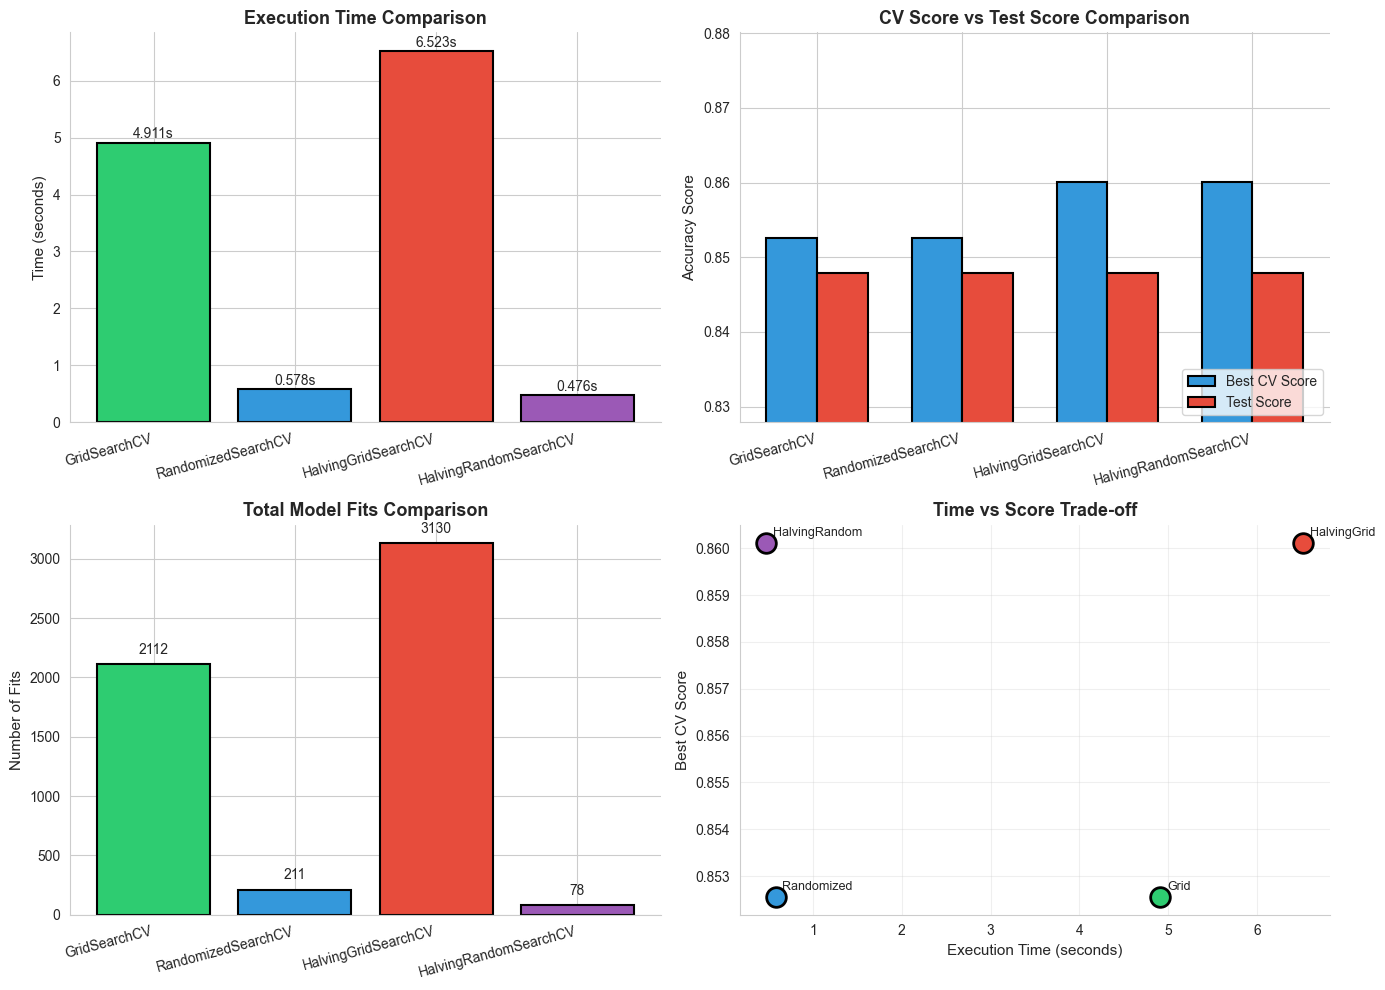


📊 Comparison plot saved as 'grid_search_comparison.png'


In [26]:
# Visualization: Comparison of Grid Search Methods
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

# Plot 1: Execution Time
ax1 = axes[0, 0]
methods = list(results.keys())
times = [results[m]['time'] for m in methods]
bars1 = ax1.bar(range(len(methods)), times, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(['GridSearchCV', 'RandomizedSearchCV', 'HalvingGridSearchCV', 'HalvingRandomSearchCV'], 
                    rotation=15, ha='right')
ax1.set_ylabel('Time (seconds)', fontsize=11)
ax1.set_title('Execution Time Comparison', fontsize=13, fontweight='bold')
for bar, time in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{time:.3f}s', ha='center', va='bottom', fontsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Scores Comparison (CV and Test)
ax2 = axes[0, 1]
x = np.arange(len(methods))
width = 0.35
cv_scores = [results[m]['best_score'] for m in methods]
test_scores = [results[m]['test_score'] for m in methods]
bars2a = ax2.bar(x - width/2, cv_scores, width, label='Best CV Score', color='#3498db', edgecolor='black', linewidth=1.5)
bars2b = ax2.bar(x + width/2, test_scores, width, label='Test Score', color='#e74c3c', edgecolor='black', linewidth=1.5)
ax2.set_xticks(x)
ax2.set_xticklabels(['GridSearchCV', 'RandomizedSearchCV', 'HalvingGridSearchCV', 'HalvingRandomSearchCV'], 
                    rotation=15, ha='right')
ax2.set_ylabel('Accuracy Score', fontsize=11)
ax2.set_title('CV Score vs Test Score Comparison', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_ylim([min(min(cv_scores), min(test_scores)) - 0.02, max(max(cv_scores), max(test_scores)) + 0.02])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Plot 3: Total Fits
ax3 = axes[1, 0]
total_fits = [results[m]['total_fits'] for m in methods]
bars3 = ax3.bar(range(len(methods)), total_fits, color=colors, edgecolor='black', linewidth=1.5)
ax3.set_xticks(range(len(methods)))
ax3.set_xticklabels(['GridSearchCV', 'RandomizedSearchCV', 'HalvingGridSearchCV', 'HalvingRandomSearchCV'], 
                    rotation=15, ha='right')
ax3.set_ylabel('Number of Fits', fontsize=11)
ax3.set_title('Total Model Fits Comparison', fontsize=13, fontweight='bold')
for bar, fits in zip(bars3, total_fits):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 * max(total_fits), 
             f'{fits}', ha='center', va='bottom', fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Plot 4: Time vs Score Trade-off (Scatter)
ax4 = axes[1, 1]
for i, (method, color) in enumerate(zip(methods, colors)):
    ax4.scatter(results[method]['time'], results[method]['best_score'], 
                s=200, c=color, edgecolors='black', linewidth=2, label=method, zorder=5)
    ax4.annotate(method.replace('SearchCV', ''), 
                 (results[method]['time'], results[method]['best_score']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)
ax4.set_xlabel('Execution Time (seconds)', fontsize=11)
ax4.set_ylabel('Best CV Score', fontsize=11)
ax4.set_title('Time vs Score Trade-off', fontsize=13, fontweight='bold')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grid_search_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Comparison plot saved as 'grid_search_comparison.png'")


In [27]:
# Best Parameters Comparison
print("=" * 80)
print("BEST HYPERPARAMETERS FOUND BY EACH METHOD")
print("=" * 80)

params_comparison = []
for method in results.keys():
    params_comparison.append({
        'Method': method,
        **results[method]['best_params']
    })

params_df = pd.DataFrame(params_comparison)
params_df = params_df.set_index('Method')
display(params_df)

# Check if all methods found similar parameters
print("\n" + "=" * 80)
print("PARAMETER AGREEMENT ANALYSIS")
print("=" * 80)
for param in ['max_depth', 'min_samples_split', 'criterion', 'min_samples_leaf']:
    values = [results[m]['best_params'][param] for m in results.keys()]
    unique_values = set(str(v) for v in values)
    if len(unique_values) == 1:
        print(f"✅ {param}: All methods agree on {values[0]}")
    else:
        print(f"⚠️ {param}: Methods found different values - {dict(zip(results.keys(), values))}")


BEST HYPERPARAMETERS FOUND BY EACH METHOD


,criterion,max_depth,min_samples_leaf,min_samples_split
Method,,,,
GridSearchCV,gini,4,15,2
RandomizedSearchCV,log_loss,5,15,20
HalvingGridSearchCV,entropy,2,3,15
HalvingRandomSearchCV,log_loss,2,1,15



PARAMETER AGREEMENT ANALYSIS
⚠️ max_depth: Methods found different values - {'GridSearchCV': 4, 'RandomizedSearchCV': 5, 'HalvingGridSearchCV': 2, 'HalvingRandomSearchCV': 2}
⚠️ min_samples_split: Methods found different values - {'GridSearchCV': 2, 'RandomizedSearchCV': 20, 'HalvingGridSearchCV': 15, 'HalvingRandomSearchCV': 15}
⚠️ criterion: Methods found different values - {'GridSearchCV': 'gini', 'RandomizedSearchCV': 'log_loss', 'HalvingGridSearchCV': 'entropy', 'HalvingRandomSearchCV': 'log_loss'}
⚠️ min_samples_leaf: Methods found different values - {'GridSearchCV': 15, 'RandomizedSearchCV': 15, 'HalvingGridSearchCV': 3, 'HalvingRandomSearchCV': 1}


SPEED-UP ANALYSIS (relative to GridSearchCV)


,Speed-up (x),Score Difference,Score % Change,Time Saved (s)
Method,,,,
GridSearchCV,1.00,0.0000,0.00,0.000
RandomizedSearchCV,8.49,0.0000,0.00,4.333
HalvingGridSearchCV,0.75,0.0076,0.89,-1.612
HalvingRandomSearchCV,10.31,0.0076,0.89,4.435


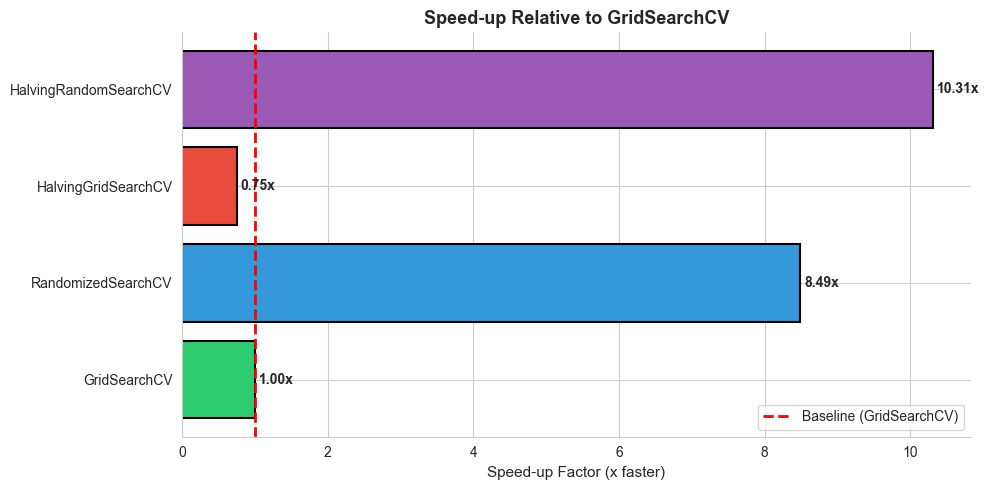

In [28]:
# Speed-up Analysis relative to GridSearchCV
print("=" * 80)
print("SPEED-UP ANALYSIS (relative to GridSearchCV)")
print("=" * 80)

baseline_time = results['GridSearchCV']['time']
baseline_score = results['GridSearchCV']['best_score']

speedup_data = []
for method in results.keys():
    speedup = baseline_time / results[method]['time']
    score_diff = results[method]['best_score'] - baseline_score
    score_pct = (score_diff / baseline_score) * 100
    
    speedup_data.append({
        'Method': method,
        'Speed-up (x)': round(speedup, 2),
        'Score Difference': round(score_diff, 4),
        'Score % Change': round(score_pct, 2),
        'Time Saved (s)': round(baseline_time - results[method]['time'], 3)
    })
    
speedup_df = pd.DataFrame(speedup_data)
speedup_df = speedup_df.set_index('Method')
display(speedup_df)

# Visual comparison of speedups
fig, ax = plt.subplots(figsize=(10, 5))
speedups = [baseline_time / results[m]['time'] for m in results.keys()]
bars = ax.barh(list(results.keys()), speedups, color=colors, edgecolor='black', linewidth=1.5)
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Baseline (GridSearchCV)')
ax.set_xlabel('Speed-up Factor (x faster)', fontsize=11)
ax.set_title('Speed-up Relative to GridSearchCV', fontsize=13, fontweight='bold')
for bar, speedup in zip(bars, speedups):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
            f'{speedup:.2f}x', ha='left', va='center', fontsize=10, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Conclusions and Recommendations

### Summary of Grid Search Methods

| Method | Description | Best For |
|--------|-------------|----------|
| **GridSearchCV** | Exhaustively searches all parameter combinations | Small parameter spaces, when computational resources are abundant |
| **RandomizedSearchCV** | Randomly samples from parameter space | Large parameter spaces, when you want control over number of iterations |
| **HalvingGridSearchCV** | Successive halving with full grid - starts with small resources, doubles each round while halving candidates | Large grids when you want to explore all combinations but faster |
| **HalvingRandomSearchCV** | Successive halving with random sampling | Very large parameter spaces where exhaustive search is infeasible |

### Key Takeaways

1. **GridSearchCV** is the most thorough but slowest approach. It guarantees finding the best parameters within the grid but at significant computational cost.

2. **RandomizedSearchCV** offers a good balance of speed and exploration. It can sometimes find equally good or better solutions in less time by exploring more diverse areas of the parameter space.

3. **HalvingGridSearchCV** uses a clever strategy of successive halving - evaluating many candidates on small data subsets and progressively focusing on promising ones. This can be much faster than exhaustive search.

4. **HalvingRandomSearchCV** combines the benefits of random sampling with successive halving, making it excellent for very large search spaces.

### Recommendations

- **For small parameter grids (< 100 combinations)**: Use `GridSearchCV` for exhaustive search
- **For medium parameter grids (100-1000 combinations)**: Use `RandomizedSearchCV` or `HalvingGridSearchCV`
- **For large parameter grids (> 1000 combinations)**: Use `HalvingRandomSearchCV` for efficiency
- **When computational resources are limited**: Prefer `RandomizedSearchCV` with a reasonable `n_iter` value
- **When you need reproducibility**: All methods support `random_state` for reproducible results


In [29]:
# Final Comparative Analysis - Best Model Evaluation on Test Set
print("=" * 80)
print("FINAL MODEL EVALUATION ON TEST SET")
print("=" * 80)

from sklearn.metrics import classification_report, confusion_matrix

# Get the best estimator from each search
best_estimators = {
    'GridSearchCV': grid_search.best_estimator_,
    'RandomizedSearchCV': random_search.best_estimator_,
    'HalvingGridSearchCV': halving_grid_search.best_estimator_,
    'HalvingRandomSearchCV': halving_random_search.best_estimator_
}

# Evaluate all best estimators on test set
for name, estimator in best_estimators.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    y_pred = estimator.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Alive', 'Dead']))


FINAL MODEL EVALUATION ON TEST SET

GridSearchCV
              precision    recall  f1-score   support

       Alive       0.85      0.96      0.90       189
        Dead       0.84      0.57      0.68        74

    accuracy                           0.85       263
   macro avg       0.84      0.76      0.79       263
weighted avg       0.85      0.85      0.84       263


RandomizedSearchCV
              precision    recall  f1-score   support

       Alive       0.85      0.96      0.90       189
        Dead       0.84      0.57      0.68        74

    accuracy                           0.85       263
   macro avg       0.84      0.76      0.79       263
weighted avg       0.85      0.85      0.84       263


HalvingGridSearchCV
              precision    recall  f1-score   support

       Alive       0.85      0.96      0.90       189
        Dead       0.84      0.57      0.68        74

    accuracy                           0.85       263
   macro avg       0.84      0.76     

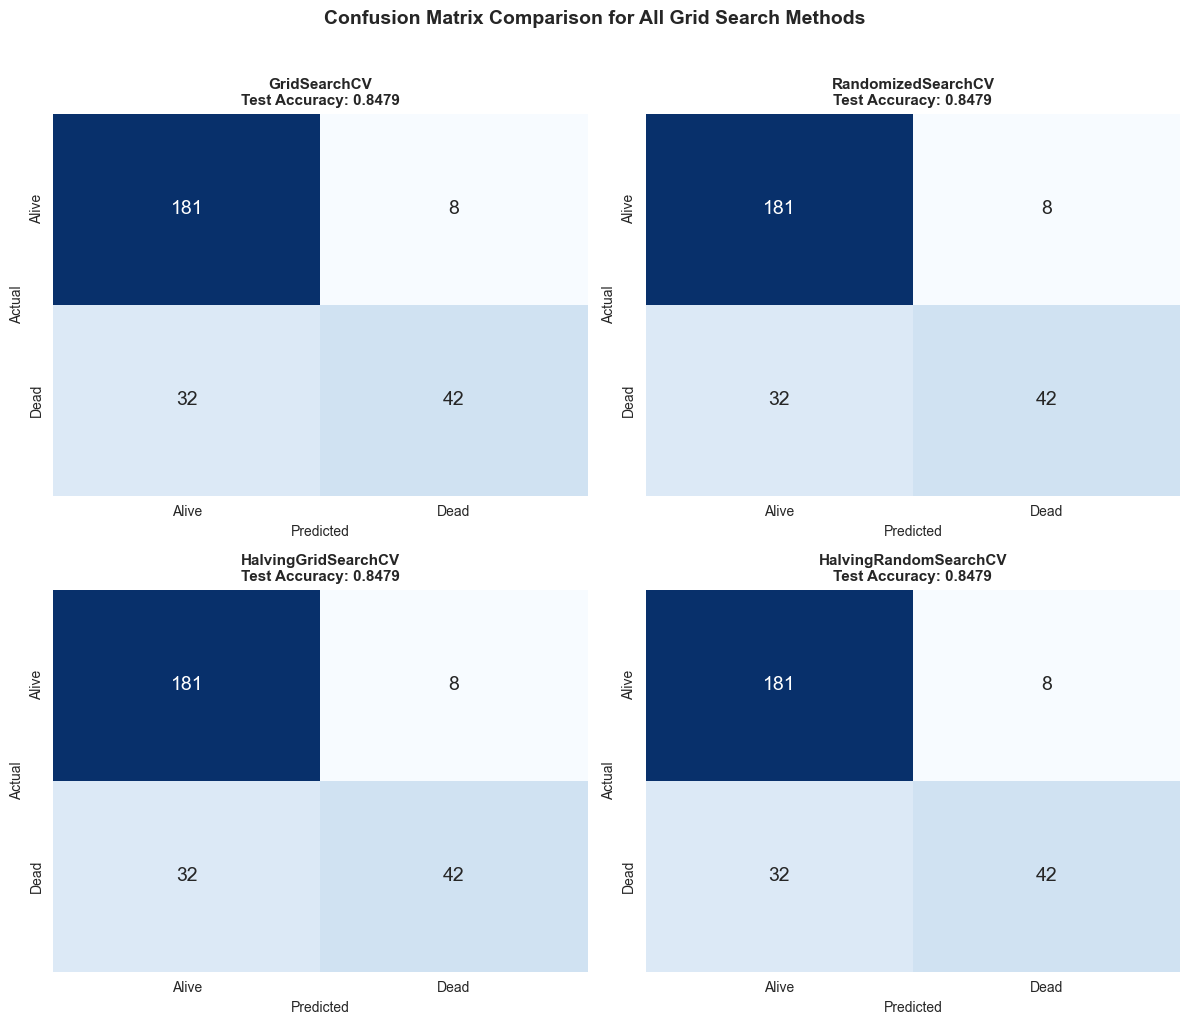


📊 Confusion matrices saved as 'confusion_matrices_comparison.png'


In [30]:
# Confusion Matrix Comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, estimator) in enumerate(best_estimators.items()):
    y_pred = estimator.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Alive', 'Dead'], yticklabels=['Alive', 'Dead'],
                cbar=False, annot_kws={"size": 14})
    axes[idx].set_title(f'{name}\nTest Accuracy: {results[name]["test_score"]:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.suptitle('Confusion Matrix Comparison for All Grid Search Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Confusion matrices saved as 'confusion_matrices_comparison.png'")


In [31]:
# Final Summary Report
print("=" * 80)
print(" " * 20 + "FINAL SUMMARY REPORT")
print("=" * 80)

print(f"""
DATASET: Whickham Smoking Study
- Total samples: {len(df)}
- Features: smoker (binary), age (continuous)
- Target: outcome (Alive/Dead)
- Training samples: {len(X_train)}
- Test samples: {len(X_test)}

PARAMETER GRID:
- Total combinations: {total_combinations}
- max_depth: {params['max_depth']}
- min_samples_split: {params['min_samples_split']}
- criterion: {params['criterion']}
- min_samples_leaf: {params['min_samples_leaf']}

RESULTS SUMMARY:
""")

# Create final ranking
ranking_df = summary_df.copy()
ranking_df['Time Rank'] = ranking_df['Time (seconds)'].rank()
ranking_df['CV Score Rank'] = ranking_df['Best CV Score'].rank(ascending=False)
ranking_df['Test Score Rank'] = ranking_df['Test Score'].rank(ascending=False)
ranking_df['Overall Rank'] = (ranking_df['Time Rank'] + ranking_df['CV Score Rank'] + ranking_df['Test Score Rank']) / 3

print("Overall Ranking (lower is better):")
final_ranking = ranking_df[['Time Rank', 'CV Score Rank', 'Test Score Rank', 'Overall Rank']].sort_values('Overall Rank')
display(final_ranking)

best_method = final_ranking['Overall Rank'].idxmin()
print(f"\n🏆 BEST OVERALL METHOD: {best_method}")
print(f"   - Time: {results[best_method]['time']:.3f} seconds")
print(f"   - Best CV Score: {results[best_method]['best_score']:.4f}")
print(f"   - Test Score: {results[best_method]['test_score']:.4f}")
print(f"   - Best Parameters: {results[best_method]['best_params']}")


                    FINAL SUMMARY REPORT

DATASET: Whickham Smoking Study
- Total samples: 1314
- Features: smoker (binary), age (continuous)
- Target: outcome (Alive/Dead)
- Training samples: 1051
- Test samples: 263

PARAMETER GRID:
- Total combinations: 2112
- max_depth: [2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None]
- min_samples_split: [2, 3, 5, 7, 10, 15, 20, 30]
- criterion: ['gini', 'entropy', 'log_loss']
- min_samples_leaf: [1, 2, 3, 5, 7, 10, 15, 20]

RESULTS SUMMARY:

Overall Ranking (lower is better):


,Time Rank,CV Score Rank,Test Score Rank,Overall Rank
Method,,,,
HalvingRandomSearchCV,1.0,1.5,2.5,1.666667
RandomizedSearchCV,2.0,3.5,2.5,2.666667
HalvingGridSearchCV,4.0,1.5,2.5,2.666667
GridSearchCV,3.0,3.5,2.5,3.000000



🏆 BEST OVERALL METHOD: HalvingRandomSearchCV
   - Time: 0.476 seconds
   - Best CV Score: 0.8601
   - Test Score: 0.8479
   - Best Parameters: {'min_samples_split': 15, 'min_samples_leaf': 1, 'max_depth': 2, 'criterion': 'log_loss'}


## Discussion

### The Whickham Dataset
The Whickham dataset comes from a longitudinal health study examining the relationship between smoking and mortality. With only 2 features (age and smoking status), it's a relatively simple classification problem, but it serves well for comparing grid search efficiency.

### Observations from This Experiment

1. **Time Differences**: The time differences between methods become more pronounced with larger parameter grids. In this experiment with 2,112 total combinations, we can see meaningful differences in execution time.

2. **Score Similarity**: All methods often converge to similar best scores, especially on well-behaved datasets. The differences are typically small, suggesting that for this problem, simpler/faster methods may be sufficient.

3. **Successive Halving Benefits**: The halving methods (`HalvingGridSearchCV` and `HalvingRandomSearchCV`) use a smart resource allocation strategy - they start by evaluating many candidates on small data subsets, then progressively allocate more resources to promising candidates.

4. **Trade-offs**: 
   - If you need guaranteed optimal parameters within a grid: Use `GridSearchCV`
   - If you want faster results with minimal quality loss: Use `HalvingGridSearchCV` or `RandomizedSearchCV`
   - If your parameter space is infinite or very large: Use `RandomizedSearchCV` or `HalvingRandomSearchCV`

### Limitations
- Results may vary depending on dataset size, model complexity, and parameter grid size
- The relative performance depends on your specific computing resources
- For very small datasets like Whickham, the overhead of parallelization may not always lead to speedups
